In [45]:
from itertools import product
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from scaling.visualize import visualize_train_curves, plot_line_fit, plot_isoflops
from pathlib import Path
from scaling.utils import (
    get_final_points_from_curve_set,
    fit_parametric_form,
    functional_form_chin3,
    fit_parametric_form_parallel
)
from sklearn.metrics import r2_score
from IPython.display import display, Math
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
sns.set_style("white")

In [56]:
unique_col_list = ["base_N", "target_N", "tkpm", "shrink", "method"]
y_col = "Validation Loss"
x_col = "flops"

N_TEST = 1217722368
mup_test =  1.5173616409301758
warm_test = 1.496509075164795


def preprocess_warmstarting(df, y_col_to_smooth=None, smoothing_window=100):
    __df = pd.DataFrame()
    for i, x in enumerate(df.groupby(unique_col_list)):
        _df = x[1].sort_values(by="flops")
        # smooth it
        if y_col_to_smooth is not None:
            # +"_smoothed"
            _df[y_col_to_smooth] = _df[y_col_to_smooth].rolling(smoothing_window, win_type='gaussian', min_periods=1).mean(std=smoothing_window / 10)
        
        # scaling tokens and flops to the max
        max_intended_tokens = (_df.iloc[-1]["target_N"] * _df.iloc[-1]["tkpm"])
        if abs((max_intended_tokens -  _df["tokens"].max()) / _df["tokens"].max()) > 0.01:
            print("Wrong tkpm: ", x[0])
            continue
        _df["tokens"] = np.round(max_intended_tokens / _df["tokens"].max() * _df["tokens"])
        
        max_intended_flops = 6. * max_intended_tokens * _df["target_N"]
        _df["flops"] = np.round(max_intended_flops / _df["flops"].max() * _df["flops"])
        
        __df = pd.concat([__df, _df])
    
    # print('Dropping tkpm <= 5')
    # __df = __df[__df['tkpm'] > 5.]
    
    return __df

def preprocess_approach3_data(df, log_transform_y=True):
    N, D, G = df["target_N"].values, df["tokens"].values, df["g"].values
    y = df["Validation Loss"].values

    _df = pd.DataFrame.from_dict({
        "N": N,
        "D": D,
        "G": G,
        "Loss": y
    }).groupby(by=["N", "D", "G"]).min().reset_index()
    _df.sort_values(by=["N", "D", "G"], inplace=True)

    data_X = _df[["N", "D", "G"]].values
    data_y = _df["Loss"].values
    if log_transform_y:
        data_y = np.log(data_y)

    return data_X, data_y

def filter_pairs(df, jump_size=1):
    distinct_values = sorted(
        pd.unique(df[['base_N', 'target_N']].values.ravel())
    )
    pairs = list(zip(distinct_values[:-jump_size], distinct_values[jump_size:]))
    df_filtered = df[df[['base_N', 'target_N']].apply(tuple, axis=1).isin(pairs)]
    return df_filtered

def format_approach3_results(params):
    _a, alpha, _b, beta, _e = params

    A = np.exp(_a)
    B = np.exp(_b)
    E = np.exp(_e)
    s = f"{A:0.2f} N^({-alpha:0.3f}) + {B:0.2f} D^({-beta:0.3f}) + {E:0.3f}"
    print(s)
    return f"{int(A)}", f"{alpha:0.3f}", f"{int(B)}", f"{beta:0.3f}", f"{E:0.3f}"

In [57]:
warmstarting_df = pd.read_parquet(
    "../data/warmstart_runs_flattened.parquet", # "../data/experimental_warmstarting.parquet" #
)
warmstarting_df = warmstarting_df.dropna(subset=[y_col])
warmstarting_df = preprocess_warmstarting(warmstarting_df)

Wrong tkpm:  (77124608, 1217722368, 10.0, 0.0, 'mup')


In [58]:
final_points_df = get_final_points_from_curve_set(
    warmstarting_df,
    unique_col_list,
    x_col="flops",
    y_col="Validation Loss",
    get_pareto=False,
)

final_points_df['g'] = final_points_df["target_N"] / final_points_df["base_N"]

In [60]:
final_points_df.groupby(by=["tkpm", "method", "target_N"]).count().reset_index()[["tkpm", "method", "target_N"]]

tag,tkpm,method,target_N
0,1.0,mup,32270848
1,1.0,mup,77124608
2,1.0,net2net,32270848
3,1.0,net2net,77124608
4,1.0,net2net,134561280
5,10.0,mup,32270848
6,10.0,mup,77124608
7,10.0,mup,134561280
8,10.0,mup,287183360
9,10.0,mup,610488320


In [61]:
def fit_chin3(data_X, data_y, dense_grid=False):
    if dense_grid:
        initialization = list(product(
            np.arange(0, 25, 1),
            np.arange(0, 2, 0.1),
            np.arange(0, 25, 1),
            np.arange(0, 2, 0.1),
            np.arange(-1, 1, 0.1)
        ))
    else:
        initialization = list(product(
            np.arange(0, 25, 5),
            np.arange(0, 2, 0.5),
            np.arange(0, 25, 5),
            np.arange(0, 2, 0.5),
            np.arange(-1, 1, 0.5)
        ))

    best_params, best_loss, df = fit_parametric_form(
        functional_form_chin3,
        data_X[:,:2],
        data_y,
        initialization,
    )

    y_true = data_y
    y_pred = functional_form_chin3(data_X[:,:2], best_params)
    r2_log = r2_score(y_true, y_pred)
    r2 = r2_score(np.exp(y_true), np.exp(y_pred))



    test_point = np.array([[N_TEST, 10 * N_TEST]])
    test_prediction = float(np.exp(functional_form_chin3(test_point, best_params))[0])

    print("Fit")
    format_approach3_results(best_params)
    print("Top fits")
    print(df.head())
    print("Quality of Fit")
    print("Test prediction: ", test_prediction, " | muP true value: ", mup_test, " | warm true value: ", warm_test)
    print("Log scaled R2: ", r2_log)
    print("R2: ", r2)

    return best_params

In [62]:
mup_df = final_points_df[final_points_df['method']=='mup']
mup_jump_df = filter_pairs(mup_df, jump_size=1)
mup_data_X, mup_data_y = preprocess_approach3_data(mup_jump_df, log_transform_y=True)
mup_params = fit_chin3(mup_data_X, mup_data_y)

y_pred = functional_form_chin3(mup_data_X[:,:2], mup_params)
mup_r2 = r2_score(np.exp(mup_data_y), np.exp(y_pred))

                A     alpha             B      beta         e      loss
19      97.404134  0.305343    454.396969  0.341139  1.239674  0.000116
322    149.182798  0.333861    460.209521  0.341985  1.274125  0.000116
402    197.780237  0.352496    463.309225  0.342437  1.293708  0.000116
1       53.389724  0.263966    453.683749  0.340967  1.178047  0.000116
401    253.585577  0.368769    466.671413  0.342909  1.309295  0.000116
..            ...       ...           ...       ...       ...       ...
744  21997.554851  0.523443    148.413159  1.000000  0.367818  0.001719
764  21997.554856  0.523443  22026.465795  1.500000  0.367818  0.001719
728  21997.554856  0.523443      1.000000  1.000000  0.367818  0.001719
748  21997.554855  0.523443    148.413159  1.500000  0.367818  0.001719
732  21997.554856  0.523443      1.000000  1.500000  0.367818  0.001719

[1600 rows x 6 columns]
Fit
97.40 N^(-0.305) + 454.40 D^(-0.341) + 1.240
Top fits
              A     alpha           B      beta      

In [63]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]
warm_jump_df = filter_pairs(warm_df, jump_size=1)
warm_data_X, warm_data_y = preprocess_approach3_data(warm_jump_df, log_transform_y=True)
warm_params = fit_chin3(warm_data_X, warm_data_y)

y_pred = functional_form_chin3(warm_data_X[:,:2], warm_params)
warm_r2 = r2_score(np.exp(warm_data_y), np.exp(y_pred))

                 A     alpha             B      beta         e      loss
22    8.146858e+02  0.422954  1.300390e+02  0.295363  1.304693  0.000004
420   7.474436e+02  0.417364  1.502346e+02  0.303602  1.306310  0.000004
401   2.464894e+02  0.345195  6.453908e+01  0.253878  1.167838  0.000005
802   2.260110e+04  0.632057  2.733861e+01  0.199988  1.296245  0.000007
641   1.781209e+04  0.617445  1.091048e+01  0.138611  1.108360  0.000007
...            ...       ...           ...       ...       ...       ...
760   2.199466e+04  0.525935  2.202647e+04  1.000000  0.367810  0.001344
796   2.199466e+04  0.525934  4.851652e+08  1.500000  0.367810  0.001344
992   3.004288e+06  1.524813  2.155307e+04  0.454706  0.368406  0.001485
1312  4.458384e+08  1.526326  2.155262e+04  0.454739  0.368108  0.001486
1396  4.582617e+08  1.530082  2.207273e+04  0.455894  0.368371  0.001490

[1600 rows x 6 columns]
Fit
814.69 N^(-0.423) + 130.04 D^(-0.295) + 1.305
Top fits
                A     alpha           B 

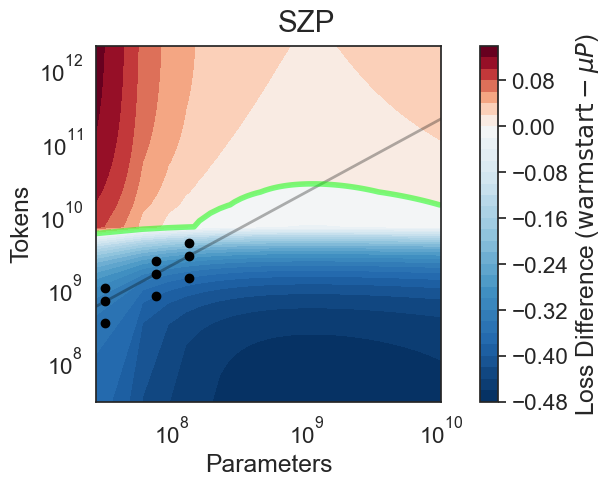

In [64]:
sns.set_context("notebook", font_scale=1.475)
fig, ax = plt.subplots(1, 1, figsize=(6, 4.75), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (warm_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor

norm = TwoSlopeNorm(vmin=L_cg.min(), vcenter=0, vmax=L_cg.max())
cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(warm_data_X[:,0], warm_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
# ax.set_title("SZP")
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()
fig.suptitle("SZP")
fig.savefig(f"figures/neurips_chinchilla_paws.pdf")

In [65]:
n2n_df = final_points_df[(final_points_df['method']=='net2net')]
n2n_jump_df = filter_pairs(n2n_df, jump_size=1)
n2n_data_X, n2n_data_y = preprocess_approach3_data(n2n_jump_df, log_transform_y=True)
n2n_params = fit_chin3(n2n_data_X, n2n_data_y)

y_pred = functional_form_chin3(n2n_data_X[:,:2], n2n_params)
n2n_r2 = r2_score(np.exp(n2n_data_y), np.exp(y_pred))

                 A     alpha             B      beta         e      loss
787   9.763770e+05  0.865876  6.231825e+02  0.371413  1.569021  0.000153
1032  5.304156e+05  0.829015  6.480181e+02  0.373843  1.563562  0.000153
960   2.585300e+06  0.924682  5.846616e+02  0.367409  1.576434  0.000153
1000  2.598977e+06  0.925020  5.875988e+02  0.367714  1.576876  0.000153
976   2.735249e+06  0.928101  5.873465e+02  0.367694  1.577543  0.000153
...            ...       ...           ...       ...       ...       ...
32    1.001707e+00 -0.027715  2.094681e+04  1.016773  0.368117  0.001475
52    1.001749e+00 -0.027714  3.107979e+06  1.521507  0.368044  0.001475
16    1.001772e+00 -0.027713  1.411143e+02  1.020242  0.368033  0.001475
321   1.403032e+02  1.014647  1.000876e+00 -0.017001  0.606923  0.001529
760   2.199311e+04  0.524735  2.202646e+04  1.000001  0.367895  0.002070

[1600 rows x 6 columns]
Fit
976377.01 N^(-0.866) + 623.18 D^(-0.371) + 1.569
Top fits
                 A     alpha         

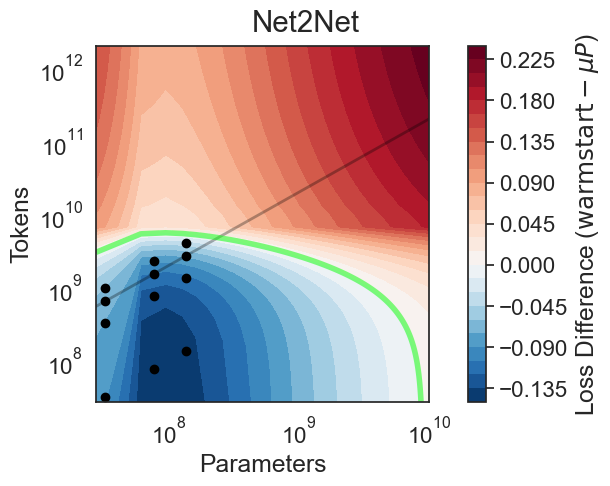

In [68]:
sns.set_context("notebook", font_scale=1.475)

fig, ax = plt.subplots(1, 1, figsize=(6, 4.75), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (n2n_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor

norm = TwoSlopeNorm(vmin=min(L_cg.min(), -0.001), vcenter=0, vmax=max(L_cg.max(),0.001))
cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(n2n_data_X[:,0], n2n_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()
fig.suptitle("Net2Net")
fig.savefig(f"figures/neurips_chinchilla_net2net.pdf")

# MLP Setting

In [ ]:
mlp_df = pd.read_parquet(
    "../data/mlp_results.parquet",
)
width_scale_to_params = {
    0: 0.1e6,
    1: 0.1e6,
    2: 0.2e6,
    3: 0.4e6,
    4: 0.9e6,
    5: 1.8e6,
    6: 3.5e6,
    7: 7.0e6,
    8: 14.2e6,
    9: 25.2e6,
    10: 100.7e6,
}
width_scale_to_hidden_dim = {
    0: 48,
    1: 68,
    2: 96,
    3: 136,
    4: 192,
    5: 272,
    6: 384,
    7: 540,
    8: 768,
    9: 1024,
    10: 2048,
}

# create base_N and target_N columns
mlp_df['base_N'] = mlp_df['base_scale'].map(lambda x: width_scale_to_hidden_dim.get(x, np.nan))
mlp_df['target_N'] = mlp_df['target_scale'].map(lambda x: width_scale_to_hidden_dim.get(x, np.nan))
mlp_df['max_flops'] = mlp_df['curve_flops'].map(lambda x: x[-1])

def get_loss_at_flops_mlp(df: pd.DataFrame, flop_intervals: list[float]) -> pd.Series:
    """Get the loss at a specific flop value by interpolation."""
    best_learning_curve = None
    best_final_loss = float('inf')

    # iterate over rows
    for row in df.itertuples(index=False):
        final_loss = row.curve_val[-1]
        if final_loss < best_final_loss:
            best_final_loss = final_loss
            best_learning_curve = pd.Series(
                data=row.curve_val,
                index=row.curve_flops
            )

    # add the flops into the Series if not present
    for flop in flop_intervals:
        if flop not in best_learning_curve.index:
            best_learning_curve.loc[flop] = np.nan
    best_learning_curve = best_learning_curve.sort_index()
    # interpolate nans
    best_learning_curve = best_learning_curve.interpolate(method='linear')
    return best_learning_curve.loc[flop_intervals]

mlp_df = mlp_df[mlp_df['scaling'] == 'width']

# Summary Table

In [67]:
data = [
    format_approach3_results(warm_params),
    format_approach3_results(n2n_params),
    format_approach3_results(mup_params),
]
columns = [r"$A$", r"$\alpha$", r"$B$",  r"$\beta$", r"$E$"]
table_df = pd.DataFrame(data, columns=columns).T
table_df.loc[r"$R^2$"] = [f"{warm_r2:0.4f}", f"{n2n_r2:0.4f}", f"{mup_r2:0.4f}"]
table_df.columns = [r"\ours{}", "Net2Net", "Scratch"]
latex = table_df.to_latex()
latex = latex.replace(r'$R^2$', r'\midrule' + '\n' + r'$R^2$')
print(latex)

814.69 N^(-0.423) + 130.04 D^(-0.295) + 1.305
976377.01 N^(-0.866) + 623.18 D^(-0.371) + 1.569
97.40 N^(-0.305) + 454.40 D^(-0.341) + 1.240
\begin{tabular}{llll}
\toprule
 & \ours{} & Net2Net & Scratch \\
\midrule
$A$ & 814 & 976377 & 97 \\
$\alpha$ & 0.423 & 0.866 & 0.305 \\
$B$ & 130 & 623 & 454 \\
$\beta$ & 0.295 & 0.371 & 0.341 \\
$E$ & 1.305 & 1.569 & 1.240 \\
\midrule
$R^2$ & 0.9999 & 0.9248 & 0.9750 \\
\bottomrule
\end{tabular}



In [28]:
warm_data_X

array([[3.22708480e+07, 3.22708480e+08, 2.21601477e+00],
       [3.22708480e+07, 6.45416960e+08, 2.21601477e+00],
       [3.22708480e+07, 9.68125440e+08, 2.21601477e+00],
       [7.71246080e+07, 7.71246080e+08, 2.38991575e+00],
       [7.71246080e+07, 1.54249216e+09, 2.38991575e+00],
       [7.71246080e+07, 2.31373824e+09, 2.38991575e+00],
       [1.34561280e+08, 1.34561280e+09, 1.74472563e+00],
       [1.34561280e+08, 2.69122560e+09, 1.74472563e+00],
       [1.34561280e+08, 4.03683840e+09, 1.74472563e+00]])

In [17]:
mup_data_y

array([0.57125126, 0.52560595, 0.48645253, 0.48786384])

In [41]:
mup_df = final_points_df[final_points_df['method']=='mup']
mup_jump_df = filter_pairs(mup_df, jump_size=2)
mup_data_X, mup_data_y = preprocess_approach3_data(mup_jump_df)
mup_params = fit_chin3(mup_data_X, mup_data_y)

Fit
11.41 N^(-0.114) + 137.35 D^(-0.274) + 0.123
Top fits
              A     alpha           b      beta         e      loss
36    11.412062  0.114243  137.354987  0.274127  0.123082  0.000018
22    11.686208  0.116505  295.112073  0.316422  0.196960  0.000019
2     23.778883  0.173257   34.504878  0.196283  0.414259  0.000023
1     50.806328  0.230468   72.495207  0.238546  0.735494  0.000025
420  109.256985  0.282618  149.800987  0.279074  0.918749  0.000027
Quality of Fit
Test prediction:  1.4048963437423325  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9983170682794408
R2:  0.9982825851749539


In [42]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]
warm_jump_df = filter_pairs(warm_df, jump_size=2)
warm_data_X, warm_data_y = preprocess_approach3_data(warm_jump_df)
warm_params = fit_chin3(warm_data_X, warm_data_y)

Fit
11.45 N^(-0.112) + 44.29 D^(-0.213) + 0.000
Top fits
             A     alpha           b      beta             e      loss
81   11.451257  0.112480   44.287862  0.213431  1.729066e-11  0.000015
672  11.422702  0.112213   45.540202  0.215098  3.248908e-05  0.000015
37   13.435376  0.127857   45.527106  0.215030  1.701234e-01  0.000016
22   13.353502  0.127257  130.184248  0.274431  2.534755e-01  0.000018
20   12.722932  0.122887  163.345450  0.286606  2.239043e-01  0.000019
Quality of Fit
Test prediction:  1.4003994881105224  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9983283545108984
R2:  0.9983218736100015


[]

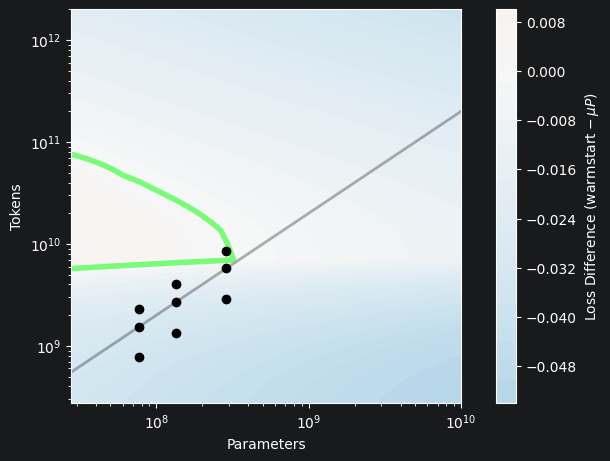

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (warm_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor


cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(warm_data_X[:,0], warm_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()

In [10]:
mup_df = final_points_df[final_points_df['method']=='mup']
mup_jump_df = filter_pairs(mup_df, jump_size=4)
mup_data_X, mup_data_y = preprocess_approach3_data(mup_jump_df)
mup_params = fit_chin3(mup_data_X, mup_data_y)

                 A     alpha             B      beta         e      loss
960   3.146388e+06  0.896259  5.349542e+01  0.196749  0.951509  0.000008
423   1.514583e+02  0.348460  1.506483e+02  0.254641  1.011924  0.000009
980   3.076830e+06  0.896514  1.507801e+02  0.254685  1.102566  0.000009
422   1.536683e+02  0.349255  1.507170e+02  0.254686  1.012375  0.000009
1460  4.241872e+08  1.158281  1.506288e+02  0.254644  1.115283  0.000009
...            ...       ...           ...       ...       ...       ...
1028  3.040118e+06  1.427485  4.770849e+08  0.876979  0.374676  0.000684
392   1.408571e+02  1.027539  4.878275e+08  0.878016  0.376042  0.000684
1112  3.102580e+06  1.527553  4.878275e+08  0.878015  0.376019  0.000684
712   2.090505e+04  1.027526  4.878274e+08  0.878013  0.375907  0.000684
1432  4.604650e+08  1.527505  4.878274e+08  0.878014  0.375907  0.000684

[1600 rows x 6 columns]
Fit
3146388.29 N^(-0.896) + 53.50 D^(-0.197) + 0.952
Top fits
                 A     alpha         

In [11]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]
warm_jump_df = filter_pairs(warm_df, jump_size=4)
warm_data_X, warm_data_y = preprocess_approach3_data(warm_jump_df)
warm_params = fit_chin3(warm_data_X, warm_data_y)

                 A     alpha             B      beta         e      loss
1352  5.256838e+08  1.134993  5.071143e+08  1.054823  1.562835  0.000015
475   1.509027e+02  0.309332  4.861122e+08  1.052830  1.329810  0.000015
794   2.147617e+04  0.592078  4.836419e+08  1.052593  1.483937  0.000015
793   1.667434e+04  0.578114  4.826940e+08  1.052466  1.479885  0.000015
1194  3.294136e+06  0.865171  4.822473e+08  1.052455  1.536336  0.000015
...            ...       ...           ...       ...       ...       ...
872   2.202655e+04  0.999924  4.878269e+08  0.877927  0.375928  0.000756
1592  4.851675e+08  1.499905  4.878269e+08  0.877928  0.375928  0.000756
712   2.090503e+04  1.027546  4.878294e+08  0.877923  0.375835  0.000756
1432  4.604645e+08  1.527526  4.878294e+08  0.877923  0.375835  0.000756
1348  4.511777e+08  1.428174  4.770852e+08  0.876878  0.373884  0.000756

[1600 rows x 6 columns]
Fit
525683785.75 N^(-1.135) + 507114320.67 D^(-1.055) + 1.563
Top fits
                 A     alpha

NameError: name 'norm' is not defined

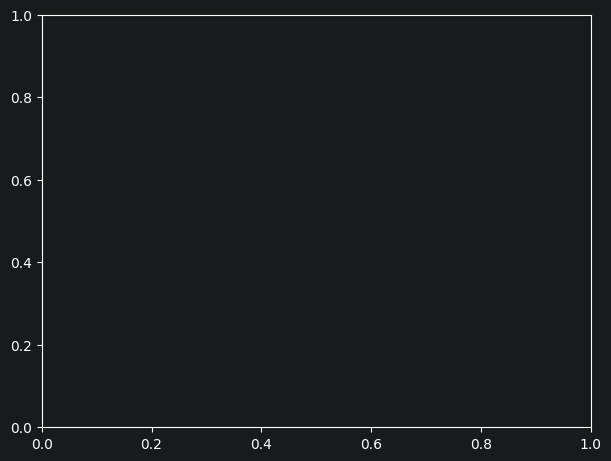

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (warm_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor


cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(warm_data_X[:,0], warm_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()

In [45]:
# Create visualizations for custom loss function
# Try fitting and look at R2 and extrapolation

In [ ]:
# Misfitting
LBFGS with different tolerrances

a_vals = np.arange(0, 25, 1)
b_vals = np.arange(0, 25, 1)
e_vals = np.arange(-1, 1, 0.1)
alpha_vals = np.arange(0, 2, 0.1)
beta_vals = np.arange(0, 2, 0.1)

a_vals = np.arange(0, 25, 5)
b_vals = np.arange(0, 25, 5)
e_vals = np.arange(-1, 1, 0.5)
alpha_vals = np.arange(0, 2, 0.5)
beta_vals = np.arange(0, 2, 0.5)


# Gemstone
method="L-BFGS-B"

for _ in range(num_parameters):
        param_search_array.append(np.arange(0, 2.5, 0.5))  # exp, 5 possible values
    for _ in range(num_parameters):
        param_search_array.append(np.arange(0, 30, 5))  # coefficient, 6 values
    param_search_array.append(np.arange(-1, 1.5, 0.5))  # error, 5 values



# mine

np.linspace(0, 15, 5),  # a
np.linspace(0., 1., 5),  # alpha
np.linspace(0, 15, 5),  # b
np.linspace(0., 1., 5),  # beta
np.linspace(0., 1., 5),  # e


# Farseer

torch.optim.LBFGS([params],
lr=1e-1,
history_size=10,
max_iter=20,
line_search_fn="strong_wolfe")

for a in np.linspace(0, 25, 5):
        for b in np.linspace(0, 25, 5):
            for e in np.linspace(-1, 1, 4):
                for alpha in np.linspace(0, 2, 4):